In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import textwrap, random, json

PARQUET = "/home/shimamoo/Bagel/data_collection/sequences/tikz/dataset.parquet"
df = pd.read_parquet(PARQUET)
print(df.shape, df.columns.tolist())
df.head(3)

(9952, 7) ['type', 'domain', 'prompt', 'code', 'image_path', 'steps', 'image_exists']


,type,domain,prompt,code,image_path,steps,image_exists
0,full,tikz,Generate a tikz program.,\documentclass{article}\n\usepackage{tikz}\n\u...,/home/shimamoo/Bagel/data_collection/rendered/...,None,True
1,full,tikz,Generate a tikz program.,\documentclass{article}\n\usepackage[utf8]{inp...,/home/shimamoo/Bagel/data_collection/rendered/...,None,True
2,full,tikz,Equilibrium types for the mean maximization pr...,\documentclass{article}\n\usepackage[T1]{fonte...,/home/shimamoo/Bagel/data_collection/rendered/...,None,True


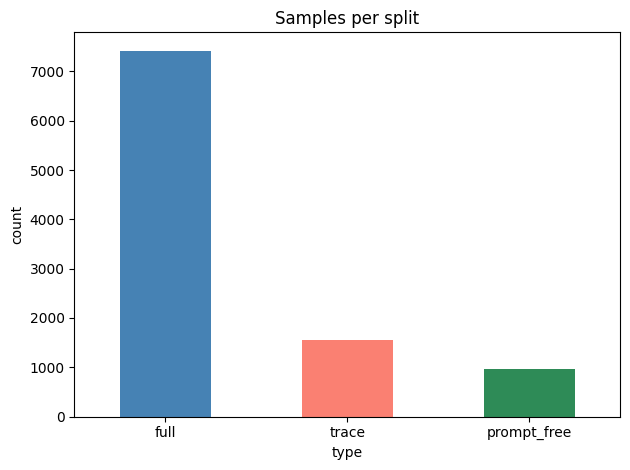

type
full           7421
trace          1557
prompt_free     974
Name: count, dtype: int64


In [2]:
# split distribution
df['type'].value_counts().plot(kind='bar', color=['steelblue','salmon','seagreen'])
plt.title('Samples per split')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['type'].value_counts())

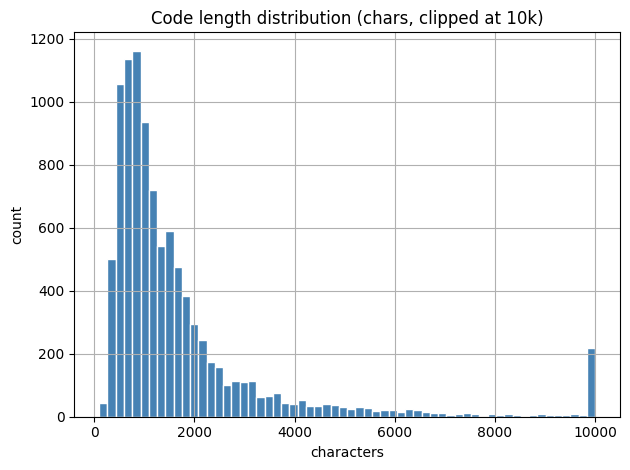

count      9952.0
mean       2046.0
std        6577.0
min          99.0
25%         723.0
50%        1116.0
75%        1869.0
max      465391.0
Name: code_len, dtype: float64


In [3]:
# code length distribution
df['code_len'] = df['code'].str.len()
df['code_len'].clip(upper=10000).hist(bins=60, color='steelblue', edgecolor='white')
plt.title('Code length distribution (chars, clipped at 10k)')
plt.xlabel('characters')
plt.ylabel('count')
plt.tight_layout()
plt.show()
print(df['code_len'].describe().round())

In [4]:
# prompt length for full split
full = df[df['type'] == 'full'].copy()
full['prompt_len'] = full['prompt'].str.len()
has_real_prompt = full[full['prompt'] != 'Generate a tikz program.']
print(f"rows with real captions: {len(has_real_prompt)} / {len(full)}")
print("\nsample captions:")
for p in has_real_prompt['prompt'].dropna().sample(min(5, len(has_real_prompt))).values:
    print(' ', textwrap.shorten(p, 100))

rows with real captions: 3867 / 7421

sample captions:
  a teddy bear above a dog
  trident emblem
  A compositional physical system
  a toolbox
  shushing face


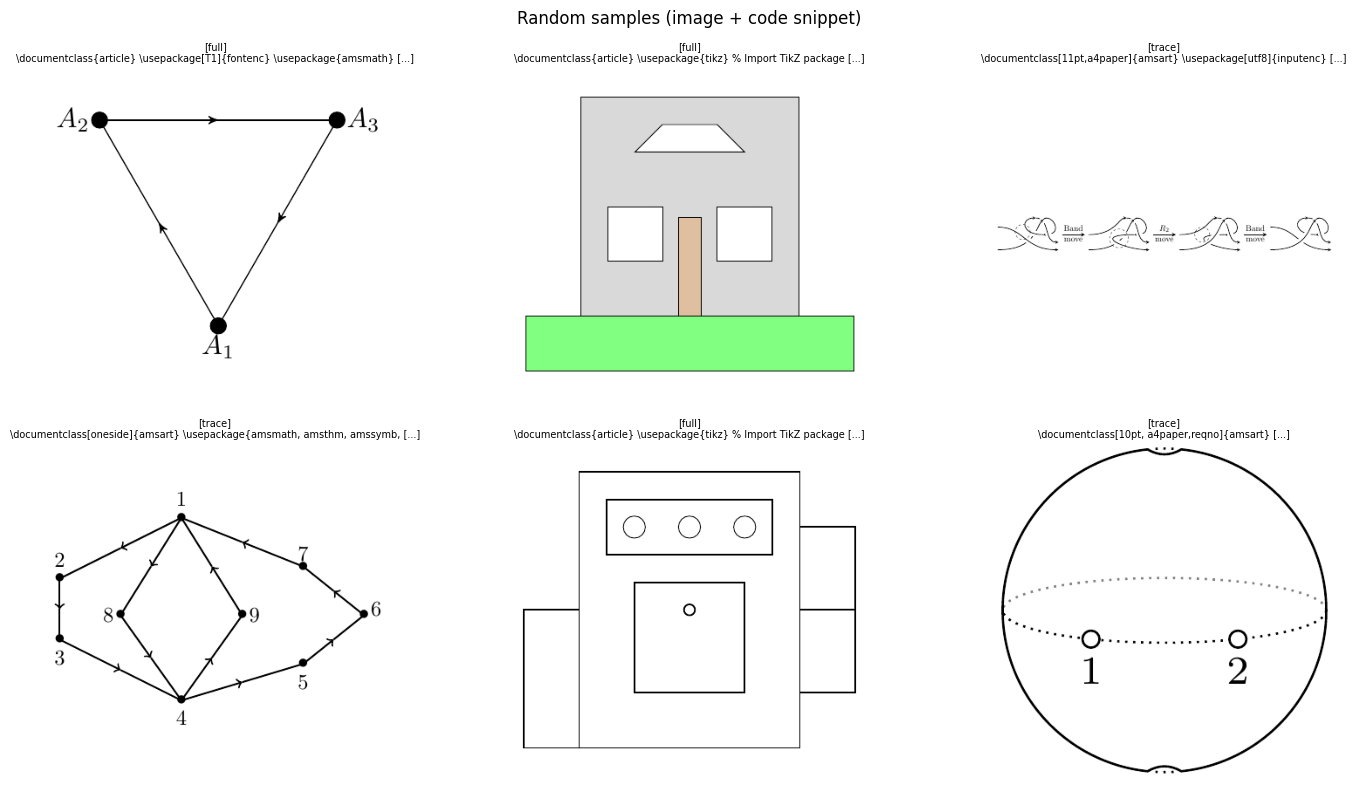

In [5]:
# show random samples: image + code side by side
sample = df[df['image_exists']].sample(6, random_state=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    try:
        img = mpimg.imread(row['image_path'])
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)
    short_code = textwrap.shorten(row['code'].replace('\n', ' '), 80)
    ax.set_title(f"[{row['type']}]\n{short_code}", fontsize=7, wrap=True)
    ax.axis('off')
plt.suptitle('Random samples (image + code snippet)', fontsize=12)
plt.tight_layout()
plt.show()

trace has 18 steps, final image: /home/shimamoo/Bagel/data_collection/rendered/tikz/28903f6cc9b907aa04333a22eab33461.png

--- step 1 ---
\documentclass[12 pt]{amsart}
\usepackage{amsmath,amssymb,amsthm,graphicx, algorithm, algorithmic, enumerate, mathrsfs, setspace, tikz, stmaryrd, mathdots, youngtab,epstopdf,comment,bm,hyperref}
\usetikzlibrary{arrows,decorations.markings}
\usetikzlibrary{patterns}

\begin{document}

\begin{tikzpict

--- step -1 (final) ---
\documentclass[12 pt]{amsart}
\usepackage{amsmath,amssymb,amsthm,graphicx, algorithm, algorithmic, enumerate, mathrsfs, setspace, tikz, stmaryrd, mathdots, youngtab,epstopdf,comment,bm,hyperref}
\usetikzlibrary{arrows,decorations.markings}
\usetikzlibrary{patterns}

\begin{document}

\begin{tikzpict


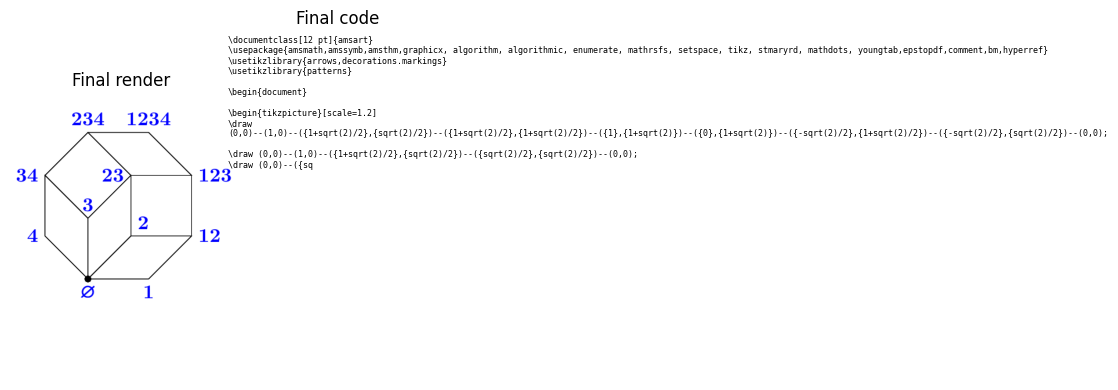

In [6]:
# show a trace example: how the TikZ program grows step by step
traces = df[df['type'] == 'trace'].dropna(subset=['steps'])
if len(traces):
    row = traces.sample(1, random_state=1).iloc[0]
    steps = json.loads(row['steps'])
    print(f"trace has {len(steps)} steps, final image: {row['image_path']}")
    print("\n--- step 1 ---")
    print(steps[0][:300])
    print("\n--- step -1 (final) ---")
    print(steps[-1][:300])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    img = mpimg.imread(row['image_path'])
    axes[0].imshow(img)
    axes[0].set_title('Final render')
    axes[0].axis('off')
    axes[1].text(0.01, 0.99, steps[-1][:600], transform=axes[1].transAxes,
                 fontsize=6, va='top', family='monospace', wrap=True)
    axes[1].set_title('Final code')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('no trace rows found')

In [7]:
# longest and shortest programs
print("=== shortest program ===")
print(df.nsmallest(1, 'code_len')['code'].values[0][:500])
print("\n=== longest program (first 500 chars) ===")
print(df.nlargest(1, 'code_len')['code'].values[0][:500])

=== shortest program ===
\documentclass[tikz]{standalone}
\usepackage{tikzlings}
\begin{document}
\tikz{\owl}
\end{document}

=== longest program (first 500 chars) ===
\documentclass[portrait,a1,final]{a0poster}

\usepackage{graphics}
\usepackage{tikz}
\usetikzlibrary{shapes,positioning,decorations.pathmorphing}
\begin{document}

\definecolor{c231F20}{RGB}{35,31,32}
\definecolor{cFFFFD0}{RGB}{255,255,208}
\definecolor{cc6e9af}{RGB}{198,233,175}
\definecolor{c80b3ff}{RGB}{128,179,255}
\definecolor{cffe680}{RGB}{255,230,128}
\definecolor{cd35f5f}{RGB}{211,95,95}
\definecolor{c338000}{RGB}{51,128,0}
\definecolor{cb380ff}{RGB}{179,128,255}
\definecolor{cF7D3AA}{RG
